# Notebook 2 — Data Packaging

Author: Eun-Kyeong Kim (eun-kyeong.kim@lxp.lu), LuxProvide S.A

## Multimodal Flood Inference with TerraMind on MeluXina HPC

**Goal:** Read the acquisition manifest produced by Notebook 1, download and
reproject each satellite asset onto a common analysis grid, and write
analysis-ready NumPy arrays plus a chip index to disk.

### What you will learn
- How to reproject multi-source rasters onto a shared UTM grid with `rasterio`
- How array dimensions are organised for multi-modal, multi-temporal data
- How to extract fixed-size spatial "chips" for deep-learning inference

### Data flow
```
manifest JSON   ──►  download & reproject  ──►  full-scene arrays (.npy)
                                           ──►  valid pixel mask (.npy)
                                           ──►  [optional] flood label (.npy)
                                           ──►  chip index (.csv)
```

---


### 1 · Imports

Key packages:
- **`rasterio`** — reads geospatial rasters and performs reprojection
- **`numpy`** — array storage and manipulation
- **`tqdm`** — progress bars for long downloads
- **`matplotlib`** — quick visual sanity-checks at the end


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
from rasterio import features
from rasterio.enums import Resampling
from rasterio.transform import from_bounds
from rasterio.warp import reproject
from shapely.geometry import box
from tqdm.auto import tqdm

import os
import shutil
import zipfile
import tempfile
from urllib.request import urlretrieve

import warnings
warnings.filterwarnings('ignore')

### 2 · Configuration

Most parameters are inherited from the manifest written by Notebook 1.
The only new ones here relate to the analysis grid and chip extraction.

| Variable | Meaning |
|---|---|
| `TARGET_RESOLUTION` | Pixel spacing of the output grid in metres |
| `CHIP_SIZE` | Side length of each spatial chip in pixels |
| `CHIP_STRIDE` | Step between chip origins in pixels (< CHIP_SIZE → overlapping chips) |
| `MIN_CHIP_VALID_FRAC` | Minimum fraction of valid (non-NaN) pixels required to keep a chip |
| `FORCE_REBUILD_*` | Set to `True` to re-download / re-compute even if cached files exist |


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
ROOT         = Path("data/terramind_flood_lux")
META_ROOT    = ROOT / "metadata"
PACKAGE_ROOT = ROOT / "package"
FULL_ROOT    = PACKAGE_ROOT / "full_scene"
FULL_ROOT.mkdir(parents=True, exist_ok=True)

# ── Load acquisition manifest ─────────────────────────────────────────────
# This file was created by Notebook 1 and tells us exactly which satellite
# scenes to download and which bands to use.
manifest   = json.loads((META_ROOT / "multimodal_acquisition_manifest.json").read_text())
EVENT      = manifest["event"]
PHASE_ORDER = manifest["phase_order"]

# ── Grid parameters ──────────────────────────────────────────────────────
TARGET_CRS        = EVENT.get("target_crs", "EPSG:32632")  # UTM zone 32N
TARGET_RESOLUTION = 10    # metres — matches Sentinel-2's 10 m native bands

# ── Chip (patch) extraction parameters ───────────────────────────────────
CHIP_SIZE            = 256   # pixels — spatial input size expected by TerraMind
CHIP_STRIDE          = 208   # pixels — step between chip origins (48 px overlap)
MIN_CHIP_VALID_FRAC  = 0.80  # drop chips with >20 % NaN pixels

# ── Band lists (inherited from the manifest) ──────────────────────────────
S2_BANDS = manifest["assets"]["S2L2A"]   # 12 Sentinel-2 bands
S1_BANDS = manifest["assets"]["S1RTC"]   # ["vv", "vh"]

# ── Output file paths ─────────────────────────────────────────────────────
# Arrays are stored as memory-mapped .npy files for fast random access.
S1RTC_PATH         = FULL_ROOT / "S1RTC_full.npy"
S2L2A_PATH         = FULL_ROOT / "S2L2A_full.npy"
DEM_PATH           = FULL_ROOT / "DEM_full.npy"
VALID_MASK_PATH    = FULL_ROOT / "valid_mask_full.npy"
FULL_META_PATH     = FULL_ROOT / "luxembourg_multimodal_4step_full_scene.json"
LABEL_PATH         = FULL_ROOT / "luxembourg_label_max_flood.npy"
CHIP_MANIFEST_PATH = PACKAGE_ROOT / "chip_manifest_multimodal.csv"

# ── Cache flags ───────────────────────────────────────────────────────────
# Set to True if you want to re-download and reprocess from scratch.
FORCE_REBUILD_FULL         = False
FORCE_REBUILD_CHIP_MANIFEST = False

# ── STAC catalogue (needed to re-sign expired asset URLs) ────────────────
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

### 3 · Build the target analysis grid

All three data sources (S1, S2, DEM) come in different native projections,
resolutions, and extents. To feed them to a single neural network we must
reproject everything onto an identical pixel grid.

`build_target_grid()` projects the WGS-84 bounding box into UTM, then defines
a regular grid at `TARGET_RESOLUTION` metres per pixel. Every subsequent
`reproject_asset_to_grid()` call warps a single raster band onto this grid.


In [3]:
def fetch_item(collection: str, item_id: str):
    """Retrieve a single STAC item by collection + ID (re-signs URLs automatically)."""
    items = list(catalog.search(collections=[collection], ids=[item_id]).items())
    if not items:
        raise KeyError(f"Item '{item_id}' not found in collection '{collection}'.")
    return items[0]


def build_target_grid() -> dict:
    """Project the ROI bounding box to UTM and return grid metadata.

    Returns a dict with keys: crs, transform, width, height, bounds.
    The rasterio `transform` maps pixel coordinates to UTM coordinates.
    """
    # Reproject the WGS-84 bounding box to the target UTM CRS
    roi = gpd.GeoDataFrame(
        {"geometry": [box(*EVENT["bbox"])]}, crs="EPSG:4326"
    ).to_crs(TARGET_CRS)
    minx, miny, maxx, maxy = roi.total_bounds

    # Compute grid dimensions (ceil so the ROI is fully covered)
    width  = int(math.ceil((maxx - minx) / TARGET_RESOLUTION))
    height = int(math.ceil((maxy - miny) / TARGET_RESOLUTION))

    # Affine transform: maps (col, row) → (easting, northing)
    transform = from_bounds(minx, miny, maxx, maxy, width, height)

    return {
        "crs":       TARGET_CRS,
        "transform": transform,
        "width":     width,
        "height":    height,
        "bounds":    [float(minx), float(miny), float(maxx), float(maxy)],
    }


grid = build_target_grid()
print(f"Analysis grid: {grid['width']} × {grid['height']} px  "
      f"@ {TARGET_RESOLUTION} m/px  ({TARGET_CRS})")
grid

Analysis grid: 6033 × 8449 px  @ 10 m/px  (EPSG:32632)


{'crs': 'EPSG:32632',
 'transform': Affine(np.float64(9.999522215554327), np.float64(0.0), np.float64(263209.339809777),
        np.float64(0.0), np.float64(-9.999990001154945), np.float64(5564086.599782167)),
 'width': 6033,
 'height': 8449,
 'bounds': [263209.339809777,
  5479596.684262409,
  323536.45733621623,
  5564086.599782167]}

### 4 · Reprojection and loading helpers

`reproject_asset_to_grid()` is the workhorse: it opens a single raster band from a
signed cloud URL and warps it to the target grid using bilinear interpolation.
No-data pixels become `NaN`.

The phase-level loaders (`load_s1_phase`, `load_s2_phase`) call this for each band
and stack the results along the channel axis.


In [4]:
def reproject_asset_to_grid(
    asset_href: str,
    grid: dict,
    resampling: Resampling = Resampling.bilinear,
    dtype: str = "float32",
) -> np.ndarray:
    """Download one raster band and reproject it onto *grid*.

    Parameters
    ----------
    asset_href : signed URL to a Cloud-Optimised GeoTIFF asset
    grid       : output of `build_target_grid()`
    resampling : interpolation method (bilinear is a safe default)
    dtype      : NumPy dtype of the output array

    Returns
    -------
    2-D array of shape (grid['height'], grid['width']), with NaN for no-data.
    """
    with rasterio.open(asset_href) as src:
        destination = np.full(
            (grid["height"], grid["width"]), np.nan, dtype=dtype
        )
        reproject(
            source=rasterio.band(src, 1),
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=grid["transform"],
            dst_crs=grid["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return destination


def phase_item(phase: str, modality: str):
    """Fetch the STAC item that was selected for *phase* and *modality* in Notebook 1."""
    entry = manifest["selected"][phase][modality]
    return fetch_item(entry["collection"], entry["id"])


def load_s1_phase(phase: str) -> np.ndarray:
    """Download and reproject S1 VV + VH for one temporal phase.

    Returns shape: (2, H, W)  — channel dimension = [VV, VH].
    """
    item = phase_item(phase, "S1RTC")
    vv   = reproject_asset_to_grid(item.assets["vv"].href, grid)
    vh   = reproject_asset_to_grid(item.assets["vh"].href, grid)
    return np.stack([vv, vh], axis=0).astype("float32")


def load_s2_phase(phase: str) -> np.ndarray:
    """Download and reproject all 12 S2 bands for one temporal phase.

    Returns shape: (12, H, W)  — one slice per band in S2_BANDS order.
    """
    item = phase_item(phase, "S2L2A")
    band_arrays = [
        reproject_asset_to_grid(item.assets[band].href, grid)
        for band in S2_BANDS
    ]
    return np.stack(band_arrays, axis=0).astype("float32")


def load_dem() -> np.ndarray:
    """Mosaic all DEM tiles covering the ROI and return a single elevation array.

    Multiple tiles are averaged over overlapping regions (nanmean).

    Returns shape: (1, H, W)  — single elevation channel.
    """
    dem_entries = manifest.get("dem_items", [])
    if not dem_entries:
        raise KeyError(
            "No DEM entries in manifest. Re-run Notebook 1 and check "
            "multimodal_acquisition_manifest.json."
        )

    tile_arrays = []
    for entry in tqdm(dem_entries, desc="Loading DEM tiles", leave=False):
        dem_item = fetch_item(entry["collection"], entry["id"])
        tile_arrays.append(
            reproject_asset_to_grid(dem_item.assets["data"].href, grid)
        )

    # Stack tiles → (n_tiles, H, W) then collapse with nanmean
    dem_mosaic = np.nanmean(
        np.stack(tile_arrays, axis=0).astype("float32"),
        axis=0,
        dtype="float32",
    )
    return dem_mosaic[None, ...]   # add channel axis → (1, H, W)

### 5 · Build and cache full-scene arrays

`save_full_scene_arrays()` loops over all four temporal phases, calls the loading
helpers, and stacks everything into 4-D arrays:

```
S1RTC : (C=2,  T=4, H, W)   — 2 polarisations × 4 phases
S2L2A : (C=12, T=4, H, W)   — 12 bands × 4 phases
DEM   : (C=1,       H, W)   — static (no time axis yet)
```

> **Why cache?**  Downloading and reprojecting ~10 GeoTIFFs from a cloud
> catalogue can take several minutes. The `FORCE_REBUILD_FULL = False` flag
> skips this work if the `.npy` files already exist on disk.


In [7]:
def save_full_scene_arrays(force: bool = False):
    """Download, reproject and stack all modalities; return memory-mapped arrays.

    If cached `.npy` files already exist and *force* is False, the files are
    memory-mapped (fast, zero-copy) rather than re-downloaded.

    Returns
    -------
    s1rtc      : (2,  4, H, W)  float32 — SAR backscatter
    s2l2a      : (12, 4, H, W)  float32 — optical reflectance
    dem_once   : (1,     H, W)  float32 — elevation
    valid_mask : (H, W)         uint8   — 1 where all modalities have valid data
    """
    # ── Fast path: load from cache ────────────────────────────────────────
    cached_files = [S1RTC_PATH, S2L2A_PATH, DEM_PATH, VALID_MASK_PATH, FULL_META_PATH]
    if (not force) and all(p.exists() for p in cached_files):
        s1rtc      = np.load(S1RTC_PATH,      mmap_mode="r")
        s2l2a      = np.load(S2L2A_PATH,      mmap_mode="r")
        dem_once   = np.load(DEM_PATH,         mmap_mode="r")
        valid_mask = np.load(VALID_MASK_PATH,  mmap_mode="r")
        print("Loaded cached full-scene arrays from disk.")
        return s1rtc, s2l2a, dem_once, valid_mask

    # ── Slow path: download and reproject all scenes ─────────────────────
    # Sentinel-1: loop over phases, stack along new time axis → (2, 4, H, W)
    s1_phases = [load_s1_phase(phase) for phase in tqdm(PHASE_ORDER, desc="Downloading S1RTC")]
    s1rtc = np.stack(s1_phases, axis=1).astype("float32")

    # Sentinel-2: same pattern → (12, 4, H, W)
    s2_phases = [load_s2_phase(phase) for phase in tqdm(PHASE_ORDER, desc="Downloading S2L2A")]
    s2l2a = np.stack(s2_phases, axis=1).astype("float32")

    # DEM: static, no time loop → (1, H, W)
    print("Downloading DEM...")
    dem_once = load_dem().astype("float32")
    print("DEM ready.")

    # ── Valid pixel mask ──────────────────────────────────────────────────
    # A pixel is 'valid' if every modality has a finite value at that location.
    # Shape: (H, W), dtype uint8 (1 = valid, 0 = masked)
    valid_mask = (
        np.isfinite(s1rtc).all(axis=(0, 1))   # all S1 channels and phases finite
        & np.isfinite(s2l2a).all(axis=(0, 1)) # all S2 channels and phases finite
        & np.isfinite(dem_once).all(axis=0)   # elevation finite
    ).astype("uint8")

    # ── Save to disk ──────────────────────────────────────────────────────
    np.save(S1RTC_PATH,      s1rtc)
    np.save(S2L2A_PATH,      s2l2a)
    np.save(DEM_PATH,        dem_once)
    np.save(VALID_MASK_PATH, valid_mask)

    full_meta = {
        "crs":                TARGET_CRS,
        "transform":          list(grid["transform"])[:6],
        "width":              grid["width"],
        "height":             grid["height"],
        "bounds":             grid["bounds"],
        "phase_order":        PHASE_ORDER,
        "s1_bands":           S1_BANDS,
        "s2_bands":           S2_BANDS,
        "chip_size":          CHIP_SIZE,
        "chip_stride":        CHIP_STRIDE,
        "min_chip_valid_frac": MIN_CHIP_VALID_FRAC,
        "full_files": {
            "S1RTC":       str(S1RTC_PATH),
            "S2L2A":       str(S2L2A_PATH),
            "DEM":         str(DEM_PATH),
            "valid_mask":  str(VALID_MASK_PATH),
        },
    }
    FULL_META_PATH.write_text(json.dumps(full_meta, indent=2))
    print("Full-scene arrays saved to disk.")
    return s1rtc, s2l2a, dem_once, valid_mask


s1rtc, s2l2a, dem_once, valid_mask = save_full_scene_arrays(force=FORCE_REBUILD_FULL)

print(f"\nArray shapes and types:")
print(f"  S1RTC      : {s1rtc.shape}  {s1rtc.dtype}  (bands, time-steps, H, W)")
print(f"  S2L2A      : {s2l2a.shape}  {s2l2a.dtype}  (bands, time-steps, H, W)")
print(f"  DEM        : {dem_once.shape}  {dem_once.dtype}  (1 channel, H, W)")
print(f"  valid_mask : {valid_mask.shape}  {valid_mask.dtype}  — {float(np.asarray(valid_mask).mean()):.1%} of pixels are valid")

Loading DEM tiles:   0%|          | 0/4 [00:00<?, ?it/s]

DEM ready.
Full-scene arrays saved to disk.

Array shapes and types:
  S1RTC      : (2, 4, 8449, 6033)  float32  (bands, time-steps, H, W)
  S2L2A      : (12, 4, 8449, 6033)  float32  (bands, time-steps, H, W)
  DEM        : (1, 8449, 6033)  float32  (1 channel, H, W)
  valid_mask : (8449, 6033)  uint8  — 80.5% of pixels are valid


### 6 · Acquire and load optional flood reference label *(Copernicus EMS)*

The Copernicus Emergency Management Service (EMS) produced a vector flood delineation for the July 2021 event. 

#### Downloading 
First, the script downloads a ZIP file from a URL, extracts it, and moves a specified `.gdb` (Esri File Geodatabase) directory to a target location. It uses a temporary workspace, safely overwrites existing data if needed, and cleans up intermediate files automatically.

In [8]:
URL = "https://mapping.emergency.copernicus.eu/download/EMSN139/EMSN139_STD_UTM32N_v01.gdb_.zip"
TARGET_DIR = Path("data/terramind_flood_lux/labels")
GDB_NAME = "EMSN139_STD_UTM32N_v01.gdb"

def download_and_extract_gdb(url: str, target_dir: Path, gdb_name: str):
    # Ensure the target directory exists
    target_dir.mkdir(parents=True, exist_ok=True)

    # Use a temporary directory for download and extraction
    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)

        zip_path = tmpdir / "download.zip"
        extract_dir = tmpdir / "extracted"

        print("Downloading zip file...")
        urlretrieve(url, zip_path)

        print("Extracting zip file...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        # Search recursively for the .gdb directory
        gdb_path = None
        for root, dirs, files in os.walk(extract_dir):
            if gdb_name in dirs:
                gdb_path = Path(root) / gdb_name
                break

        if gdb_path is None:
            raise FileNotFoundError(f"{gdb_name} was not found in the extracted files")

        destination = target_dir / gdb_name

        # Remove existing destination directory if it already exists
        if destination.exists():
            shutil.rmtree(destination)

        print("Moving .gdb directory to target location...")
        shutil.move(str(gdb_path), destination)

        print(f"Done. File moved to: {TARGET_DIR}/{GDB_NAME}")
        

if __name__ == "__main__":
    download_and_extract_gdb(URL, TARGET_DIR, GDB_NAME)

Extracting zip file...
Moving .gdb directory to target location...
Done. File moved to: data/terramind_flood_lux/labels/EMSN139_STD_UTM32N_v01.gdb


#### Rasterization

Now, if the geodatabase (.gdb) file `data/terramind_flood_lux/labels/EMSN139_STD_UTM32N_v01.gdb` is present, this cell rasterises the maximum flood extent onto the analysis grid and saves it as `luxembourg_label_max_flood.npy`.

If the file is absent the cell prints `None` and execution continues — the label is not required for inference, only for the optional visualisation below.

In [9]:
FLOOD_GDB_PATH = TARGET_DIR/GDB_NAME

def load_optional_ems_label():
    """Rasterise the Copernicus EMS flood layer if the geodatabase is on disk.

    Returns a uint8 array (H, W) with 1 = flooded, 0 = dry, or None if the
    file is not found.
    """
    gdb_path = Path(FLOOD_GDB_PATH)
    if not gdb_path.exists():
        print("EMS geodatabase not found — skipping label generation.")
        return None

    # Try layers in preference order (maximum flood extent first)
    preferred_layers = [
        "P06TMFL01_MaxFloodExtent",
        "EMSN139_STD_UTM32N_P06TMFL_FloodTempEvolution_15072021",
        "EMSN139_STD_UTM32N_P06TMFL_FloodTempEvolution_16072021",
        "EMSN139_STD_UTM32N_P06TMFL_FloodTempEvolution_17072021",
        "EMSN139_STD_UTM32N_P04FLDEL01_FloodExtent",
        "EMSN139_STD_UTM32N_P04FLDEL02_FloodExtent",
    ]

    flood_gdf, chosen_layer = None, None
    for layer in preferred_layers:
        try:
            gdf = gpd.read_file(gdb_path, layer=layer)
            if not gdf.empty:
                flood_gdf, chosen_layer = gdf, layer
                break
        except Exception:
            continue

    if flood_gdf is None:
        print("No usable flood layer found in the geodatabase.")
        return None

    # Reproject to the analysis CRS and burn polygons to a binary raster
    flood_gdf = flood_gdf.to_crs(grid["crs"])
    flood_mask = features.rasterize(
        [(geom, 1) for geom in flood_gdf.geometry
         if geom is not None and not geom.is_empty],
        out_shape=(grid["height"], grid["width"]),
        transform=grid["transform"],
        fill=0,
        dtype="uint8",
    )
    np.save(LABEL_PATH, flood_mask)
    print(f"Flood label saved  ({chosen_layer})")
    print(f"  Flooded fraction : {float(flood_mask.mean()):.3%}")
    return flood_mask


# Load from cache if already saved, otherwise generate from the geodatabase
flood_label = (
    np.load(LABEL_PATH)
    if LABEL_PATH.exists()
    else load_optional_ems_label()
)
print(
    "flood_label:",
    None if flood_label is None
    else {"shape": flood_label.shape, "positive_frac": float(flood_label.mean())},
)

Flood label saved  (P06TMFL01_MaxFloodExtent)
  Flooded fraction : 1.342%
flood_label: {'shape': (8449, 6033), 'positive_frac': 0.013422821030275804}


### 7 · Build chip index (sliding-window extraction)

Deep-learning models like TerraMind work on fixed-size spatial patches ("chips").
`build_chip_manifest()` slides a `CHIP_SIZE × CHIP_SIZE` window over the full scene
in steps of `CHIP_STRIDE` pixels and records each valid chip's pixel coordinates.

Chips that contain too many NaN pixels (< `MIN_CHIP_VALID_FRAC` valid) are dropped.
The result is a CSV with one row per chip: its unique ID, bounding pixel indices,
and quality metrics.

> **Overlap:** `CHIP_SIZE=256` with `CHIP_STRIDE=208` means adjacent chips share
> 48 pixels of overlap. This ensures the model sees every region at slightly
> different spatial offsets, reducing boundary artefacts.


In [10]:
def build_chip_manifest(force: bool = False) -> pd.DataFrame:
    """Slide a window over the full scene and record valid chip locations.

    Returns a DataFrame with columns:
        chip_id, row0, row1, col0, col1, chip_valid_fraction, label_fraction
    """
    if CHIP_MANIFEST_PATH.exists() and not force:
        chip_df = pd.read_csv(CHIP_MANIFEST_PATH)
        print(f"Loaded cached chip manifest ({len(chip_df)} chips).")
        return chip_df

    H, W = grid["height"], grid["width"]
    chip_rows = []

    # Count valid windows first so the progress bar is accurate
    n_windows = sum(
        1
        for row0 in range(0, max(H - CHIP_SIZE + 1, 1), CHIP_STRIDE)
        for col0 in range(0, max(W - CHIP_SIZE + 1, 1), CHIP_STRIDE)
        if (min(row0 + CHIP_SIZE, H) - row0 == CHIP_SIZE
            and min(col0 + CHIP_SIZE, W) - col0 == CHIP_SIZE)
    )

    with tqdm(total=n_windows, desc="Indexing chips") as pbar:
        for row0 in range(0, max(H - CHIP_SIZE + 1, 1), CHIP_STRIDE):
            for col0 in range(0, max(W - CHIP_SIZE + 1, 1), CHIP_STRIDE):
                row1 = min(row0 + CHIP_SIZE, H)
                col1 = min(col0 + CHIP_SIZE, W)

                # Skip partial chips at the scene boundary
                if row1 - row0 != CHIP_SIZE or col1 - col0 != CHIP_SIZE:
                    continue

                pbar.update(1)

                # Fraction of valid pixels in this chip
                chip_valid_frac = float(
                    np.asarray(valid_mask[row0:row1, col0:col1])
                    .astype(bool).mean()
                )

                # Drop chips that are mostly NaN (e.g., at the edge of the swath)
                if chip_valid_frac < MIN_CHIP_VALID_FRAC:
                    continue

                # Optional: fraction of flood pixels in the reference label
                label_frac = None
                if flood_label is not None:
                    label_frac = float(
                        np.asarray(flood_label[row0:row1, col0:col1]).mean()
                    )

                chip_rows.append({
                    "chip_id":              f"lux_{row0:05d}_{col0:05d}",
                    "row0": row0, "row1": row1,
                    "col0": col0, "col1": col1,
                    "chip_valid_fraction":  chip_valid_frac,
                    "label_fraction":       label_frac,
                })

    chip_df = pd.DataFrame(chip_rows)
    chip_df.to_csv(CHIP_MANIFEST_PATH, index=False)
    print(f"Chip manifest saved: {len(chip_df)} valid chips → {CHIP_MANIFEST_PATH}")
    return chip_df


chip_df = build_chip_manifest(force=FORCE_REBUILD_CHIP_MANIFEST)
print(f"Total valid chips : {len(chip_df)}")
chip_df.head()

Indexing chips:   0%|          | 0/1120 [00:00<?, ?it/s]

Chip manifest saved: 890 valid chips → data/terramind_flood_lux/package/chip_manifest_multimodal.csv
Total valid chips : 890


,chip_id,row0,row1,col0,col1,chip_valid_fraction,label_fraction
0,lux_00000_00832,0,256,832,1088,0.987473,0.0
1,lux_00000_01040,0,256,1040,1296,1.000000,0.0
2,lux_00000_01248,0,256,1248,1504,1.000000,0.0
3,lux_00000_01456,0,256,1456,1712,1.000000,0.0
4,lux_00000_01664,0,256,1664,1920,1.000000,0.0


### 8 · Quick sanity check: event snapshot

Before moving on, let's look at the event-phase data to confirm the
download and reprojection worked correctly.

- **Left:** Sentinel-2 true-colour RGB (bands B04/B03/B02).
- **Centre:** Sentinel-1 VV channel in dB. Water appears dark (specular reflection
  scatters energy away from the sensor); flooded areas stand out against brighter land.
- **Right *(if label available)*:** Reference EMS flood outline overlaid on the RGB.


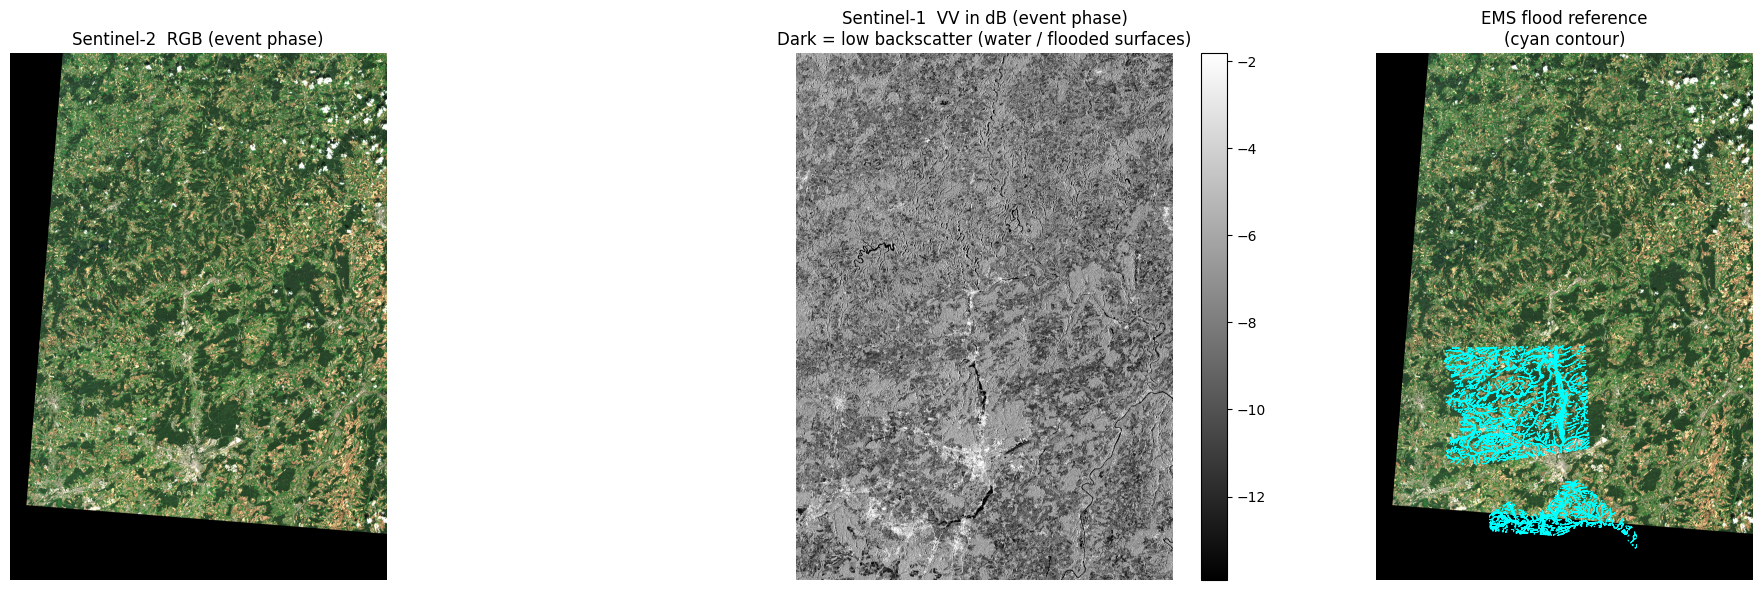

Valid pixel fraction (all modalities): 80.5%


In [11]:
event_idx = PHASE_ORDER.index("event")   # time-step index for the flood peak

# ── S2 RGB ────────────────────────────────────────────────────────────────
# Stack B04 (red), B03 (green), B02 (blue) for a natural-colour composite
rgb = np.stack(
    [
        np.asarray(s2l2a[S2_BANDS.index("B04"), event_idx]),
        np.asarray(s2l2a[S2_BANDS.index("B03"), event_idx]),
        np.asarray(s2l2a[S2_BANDS.index("B02"), event_idx]),
    ],
    axis=-1,
).astype("float32")

# Normalise to [0, 1] using the 98th percentile to avoid blowouts
rgb_finite = np.isfinite(rgb).all(axis=-1)
rgb        = np.nan_to_num(rgb, nan=0.0)
if rgb_finite.any():
    scale = np.percentile(rgb[rgb_finite], 98)
    if scale > 0:
        rgb = np.clip(rgb / scale, 0, 1)

# ── S1 VV in decibels ────────────────────────────────────────────────────
vv = np.asarray(s1rtc[0, event_idx]).astype("float32")
vv_finite = np.isfinite(vv) & (vv > 0)
vv_db = np.full_like(vv, np.nan)
vv_db[vv_finite] = 10.0 * np.log10(vv[vv_finite])
vv_ma = np.ma.masked_invalid(vv_db)
vv_vmin, vv_vmax = (
    (-25, 5) if not np.isfinite(vv_db).any()
    else np.nanpercentile(vv_db[np.isfinite(vv_db)], [2, 98])
)

# ── Plot ─────────────────────────────────────────────────────────────────
ncols = 3 if LABEL_PATH.exists() else 2
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2  RGB (event phase)")
axes[0].axis("off")

im = axes[1].imshow(vv_ma, cmap="gray", vmin=vv_vmin, vmax=vv_vmax)
axes[1].set_title("Sentinel-1  VV in dB (event phase)\n"
                  "Dark = low backscatter (water / flooded surfaces)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

if LABEL_PATH.exists():
    axes[2].imshow(rgb)
    axes[2].contour(np.load(LABEL_PATH), levels=[0.5], colors="cyan", linewidths=0.6)
    axes[2].set_title("EMS flood reference\n(cyan contour)")
    axes[2].axis("off")

plt.tight_layout()
plt.show()

valid = np.asarray(valid_mask).astype(bool)
print(f"Valid pixel fraction (all modalities): {float(valid.mean()):.1%}")

### 9 · Full multimodal alignment overview

This grid shows all four temporal phases × five data layers.
It lets you visually verify that the scenes are correctly co-registered and that
temporal changes (especially in the SAR channels) are apparent around the flood event.

Columns: **S2 RGB · S1 VV (dB) · S1 VH (dB) · DEM · valid mask**


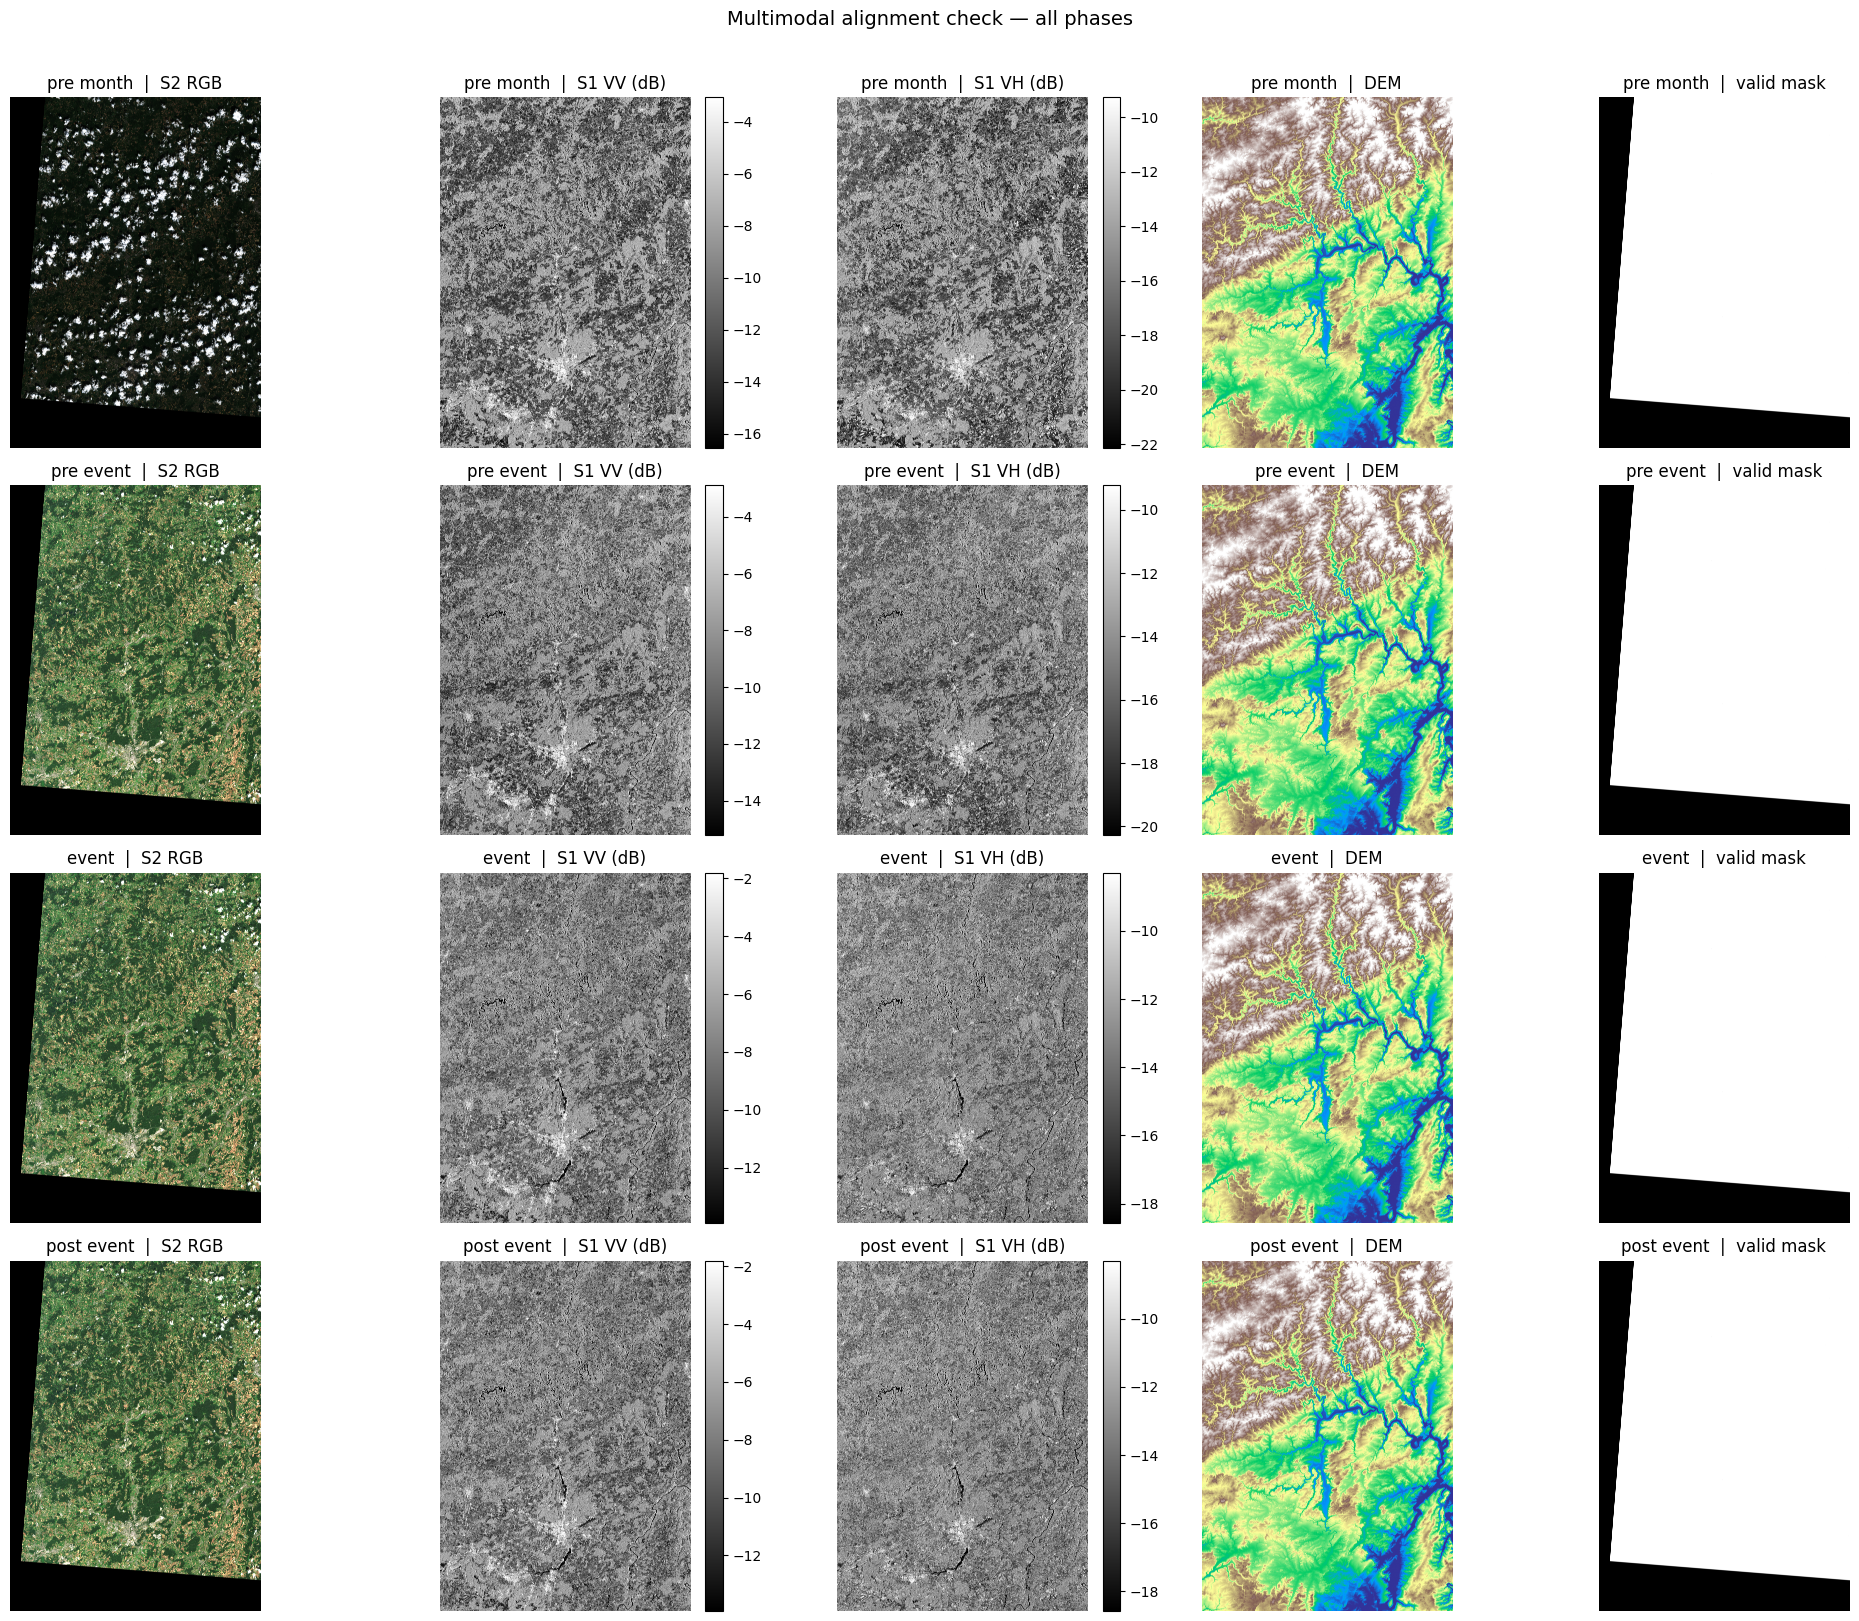

In [12]:
def linear_stretch(array: np.ndarray, mask: np.ndarray | None = None,
                   p_low: float = 2, p_high: float = 98) -> np.ndarray:
    """Stretch array values to [0, 1] using percentile clipping.

    Useful for visualising images with very different dynamic ranges.
    """
    array = array.astype("float32")
    if mask is None:
        mask = np.isfinite(array)
    if mask.sum() == 0:
        return np.zeros_like(array)
    lo, hi = np.nanpercentile(array[mask], [p_low, p_high])
    if not (np.isfinite(lo) and np.isfinite(hi) and hi > lo):
        return np.zeros_like(array)
    return np.clip((array - lo) / (hi - lo), 0, 1)


dem_2d = np.asarray(dem_once[0])   # squeeze channel axis for display
fig, axes = plt.subplots(len(PHASE_ORDER), 5,
                         figsize=(20, 4 * len(PHASE_ORDER)),
                         squeeze=False)

for row_idx, phase in enumerate(PHASE_ORDER):
    t = PHASE_ORDER.index(phase)   # time-step index

    # ── S2 RGB ────────────────────────────────────────────────────────────
    rgb_t = np.stack(
        [np.asarray(s2l2a[S2_BANDS.index("B04"), t]),
         np.asarray(s2l2a[S2_BANDS.index("B03"), t]),
         np.asarray(s2l2a[S2_BANDS.index("B02"), t])],
        axis=-1,
    ).astype("float32")
    rgb_fin = np.isfinite(rgb_t).all(axis=-1)
    rgb_t   = np.nan_to_num(rgb_t, nan=0.0)
    if rgb_fin.any():
        scale = np.percentile(rgb_t[rgb_fin], 98)
        if scale > 0:
            rgb_t = np.clip(rgb_t / scale, 0, 1)

    # ── S1 VV / VH in dB ──────────────────────────────────────────────────
    vv_t, vh_t = (np.asarray(s1rtc[c, t]).astype("float32") for c in range(2))
    vv_db_t = np.full_like(vv_t, np.nan)
    vh_db_t = np.full_like(vh_t, np.nan)
    vv_ok = np.isfinite(vv_t) & (vv_t > 0)
    vh_ok = np.isfinite(vh_t) & (vh_t > 0)
    vv_db_t[vv_ok] = 10.0 * np.log10(vv_t[vv_ok])
    vh_db_t[vh_ok] = 10.0 * np.log10(vh_t[vh_ok])

    vv_min, vv_max = ((-25, 5)  if not np.isfinite(vv_db_t).any()
                      else np.nanpercentile(vv_db_t[np.isfinite(vv_db_t)], [2, 98]))
    vh_min, vh_max = ((-30, 0)  if not np.isfinite(vh_db_t).any()
                      else np.nanpercentile(vh_db_t[np.isfinite(vh_db_t)], [2, 98]))

    # ── Plot row ──────────────────────────────────────────────────────────
    label = phase.replace("_", " ")

    axes[row_idx, 0].imshow(rgb_t)
    axes[row_idx, 0].set_title(f"{label}  |  S2 RGB");  axes[row_idx, 0].axis("off")

    im1 = axes[row_idx, 1].imshow(np.ma.masked_invalid(vv_db_t),
                                   cmap="gray", vmin=vv_min, vmax=vv_max)
    axes[row_idx, 1].set_title(f"{label}  |  S1 VV (dB)");  axes[row_idx, 1].axis("off")
    plt.colorbar(im1, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)

    im2 = axes[row_idx, 2].imshow(np.ma.masked_invalid(vh_db_t),
                                   cmap="gray", vmin=vh_min, vmax=vh_max)
    axes[row_idx, 2].set_title(f"{label}  |  S1 VH (dB)");  axes[row_idx, 2].axis("off")
    plt.colorbar(im2, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    axes[row_idx, 3].imshow(linear_stretch(dem_2d, mask=np.isfinite(dem_2d)), cmap="terrain")
    axes[row_idx, 3].set_title(f"{label}  |  DEM");  axes[row_idx, 3].axis("off")

    axes[row_idx, 4].imshow(np.asarray(valid_mask).astype(bool), cmap="gray", vmin=0, vmax=1)
    axes[row_idx, 4].set_title(f"{label}  |  valid mask");  axes[row_idx, 4].axis("off")

plt.suptitle("Multimodal alignment check — all phases", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()